# Supernode Detection

Enter a symmetric matrix (dense or scipy.sparse), run `solvers.identify_supernodes` (bound from `linear_system/supernodes.h`), and plot the sparsity pattern with detected supernode blocks overlaid.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "CMakeLists.txt").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python"))

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import solvers

assert solvers.identify_supernodes is not None, "build supernodes_ext first (cmake --build build --target supernodes_ext)"

## Enter your matrix here

Edit `A` below. It must be square and symmetric (only the upper triangle is used for supernode detection). A couple of helpers are provided to build test matrices with dense diagonal blocks.

In [2]:
def block_spd_matrix(n, dense_blocks, diag=8.0, off=0.25):
    """n x n SPD matrix with dense diagonal blocks at the given (lo, hi) ranges (inclusive)."""
    A = np.eye(n) * diag
    for lo, hi in dense_blocks:
        for i in range(lo, hi + 1):
            for j in range(lo, hi + 1):
                if i != j:
                    A[i, j] = off
    return A


# Example: 12x12 with three dense blocks -> should merge into supernodes.
A = block_spd_matrix(12, [(0, 2), (4, 6), (9, 11)])

# --- or enter your own matrix directly ---
# A = np.array([
#     [4, 1, 0, 0],
#     [1, 4, 1, 0],
#     [0, 1, 4, 1],
#     [0, 0, 1, 4],
# ], dtype=float)

A

array([[8.  , 0.25, 0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.25, 8.  , 0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.25, 0.25, 8.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 8.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 8.  , 0.25, 0.25, 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.25, 8.  , 0.25, 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.25, 0.25, 8.  , 0.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 8.  , 0.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 8.  , 0.  , 0.  ,
        0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 8.  , 0.25,
        0.25],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.25, 8.  ,
        0.25],
       [0.  , 0.  , 0

In [3]:
result = solvers.identify_supernodes(A)

print("num_supernodes:", result["num_supernodes"])
print("ranges (lo, hi):", result["ranges"])
print("col2sn:", result["col2sn"])
print("etree:", result["etree"])
print("postorder:", result["post"])

num_supernodes: 6
ranges (lo, hi): [(0, 2), (3, 3), (4, 6), (7, 7), (8, 8), (9, 11)]
col2sn: [0, 0, 0, 1, 2, 2, 2, 3, 4, 5, 5, 5]
etree: [1, 2, -1, -1, 5, 6, -1, -1, -1, 10, 11, -1]
postorder: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## Plot: sparsity pattern with supernode blocks

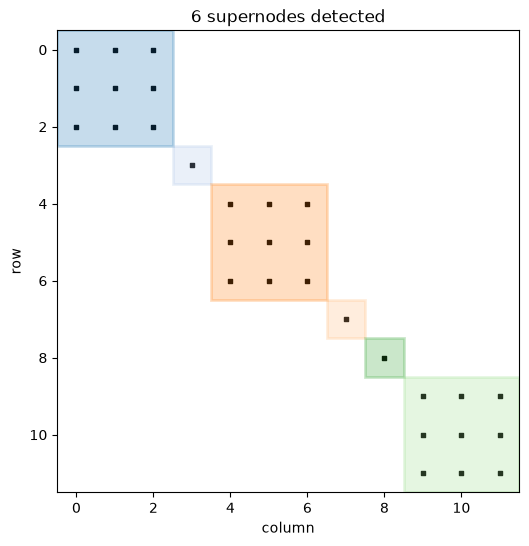

In [4]:
def plot_supernodes(A, result, ax=None):
    n = A.shape[0]
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    rows, cols = np.nonzero(A)
    ax.scatter(cols, rows, s=12, c="black", marker="s")

    cmap = plt.get_cmap("tab20")
    for sid, (lo, hi) in enumerate(result["ranges"]):
        size = hi - lo + 1
        rect = patches.Rectangle(
            (lo - 0.5, lo - 0.5), size, size,
            linewidth=2, edgecolor=cmap(sid % 20), facecolor=cmap(sid % 20), alpha=0.25,
        )
        ax.add_patch(rect)

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_title(f"{result['num_supernodes']} supernodes detected")
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    return ax


plot_supernodes(A, result)
plt.show()

## Try another matrix

A larger example with multiple non-adjacent dense blocks of varying size.

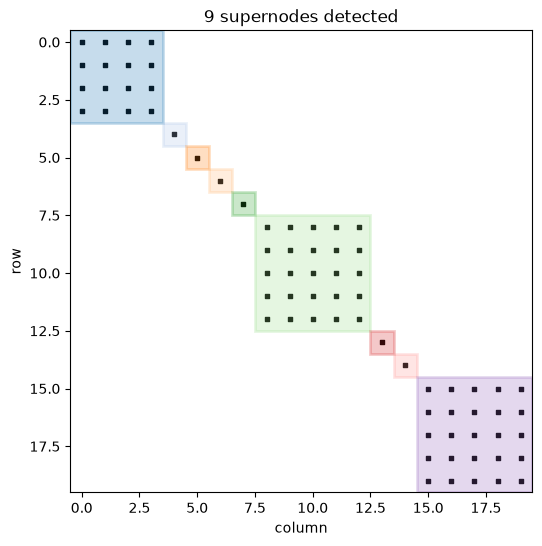

ranges: [(0, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 12), (13, 13), (14, 14), (15, 19)]


In [5]:
A2 = block_spd_matrix(20, [(0, 3), (6, 6), (8, 12), (15, 19)])
result2 = solvers.identify_supernodes(A2)

plot_supernodes(A2, result2)
plt.show()

print("ranges:", result2["ranges"])

## scipy.sparse input also works

In [6]:
A_sparse = sp.csc_matrix(A2)
result_sparse = solvers.identify_supernodes(A_sparse)
assert result_sparse["ranges"] == result2["ranges"]
print("sparse input matches dense input:", result_sparse["ranges"])

sparse input matches dense input: [(0, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 12), (13, 13), (14, 14), (15, 19)]
